## Phase-1
### Import libraries

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load dataset

In [27]:
sns.set(style="whitegrid")

df_raw = pd.read_csv("/Users/thakur/Documents/Documents-Alok-MacBook-Air/LearnPython/SAFE-AI-Fraud-Investigation/data/raw/creditcard.csv")
df = df_raw.copy()
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### Basic Info

In [28]:
print ("Shape of dataset:", df.shape)
df.info()
df.isnull().sum()

Shape of dataset: (284807, 31)
<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  flo

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

### Class Distribution

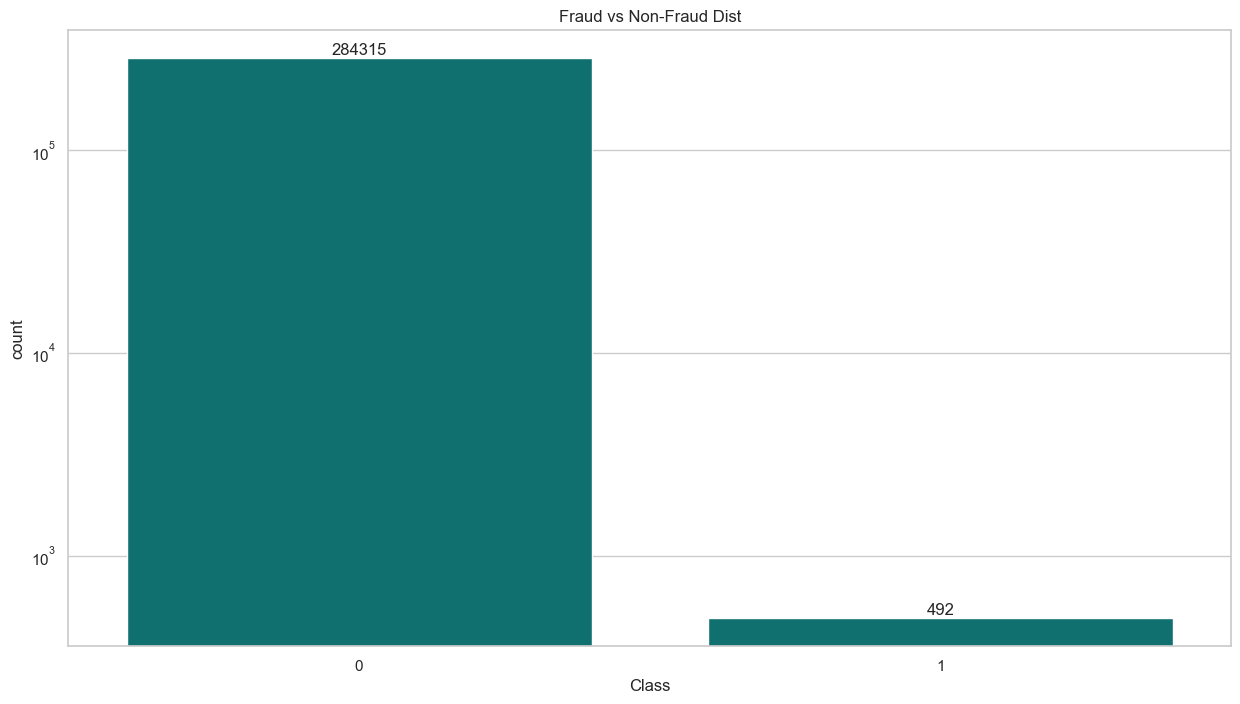

In [29]:
df["Class"].value_counts()
plt.figure(figsize=(15,8))
ax = sns.countplot(x="Class", data=df, color="teal")
ax.bar_label(ax.containers[0])
plt.yscale('log')
plt.title("Fraud vs Non-Fraud Dist")
plt.show()

1. The dataset is highly imbalanced
2. Fraud cases (class=1) are extremely rare compared to non-fraud
3. This imbalance makes fraud detection challenging

### Amount Distribution

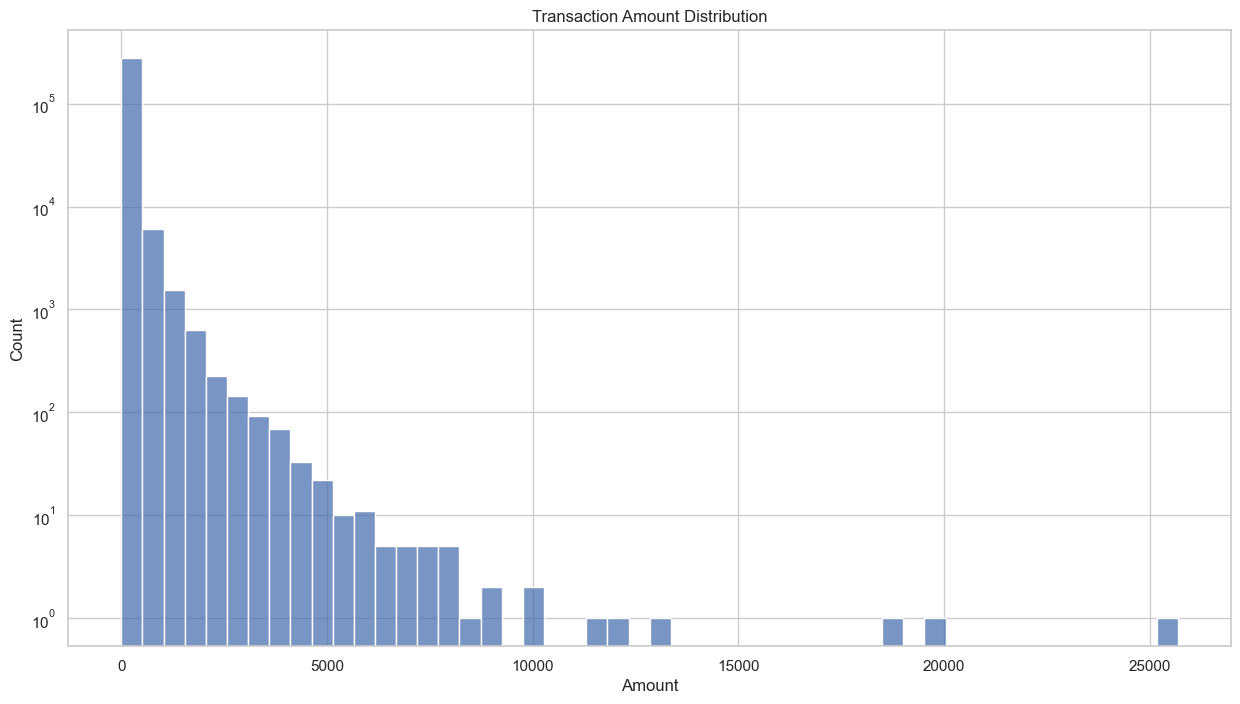

In [30]:
plt.figure(figsize=(15,8))
sns.histplot(df["Amount"], bins=50)
plt.yscale('log')
plt.title("Transaction Amount Distribution")
plt.show()

1. Most transactions are concentrated at very low amounts
2. A few high-value transactions create a long tail
3. The distribution is highly skewed
4. Log transformation helps reveal underlying patterns

### Time Distribution
In this dataset `Time` is the seconds elapsed since the first transaction.

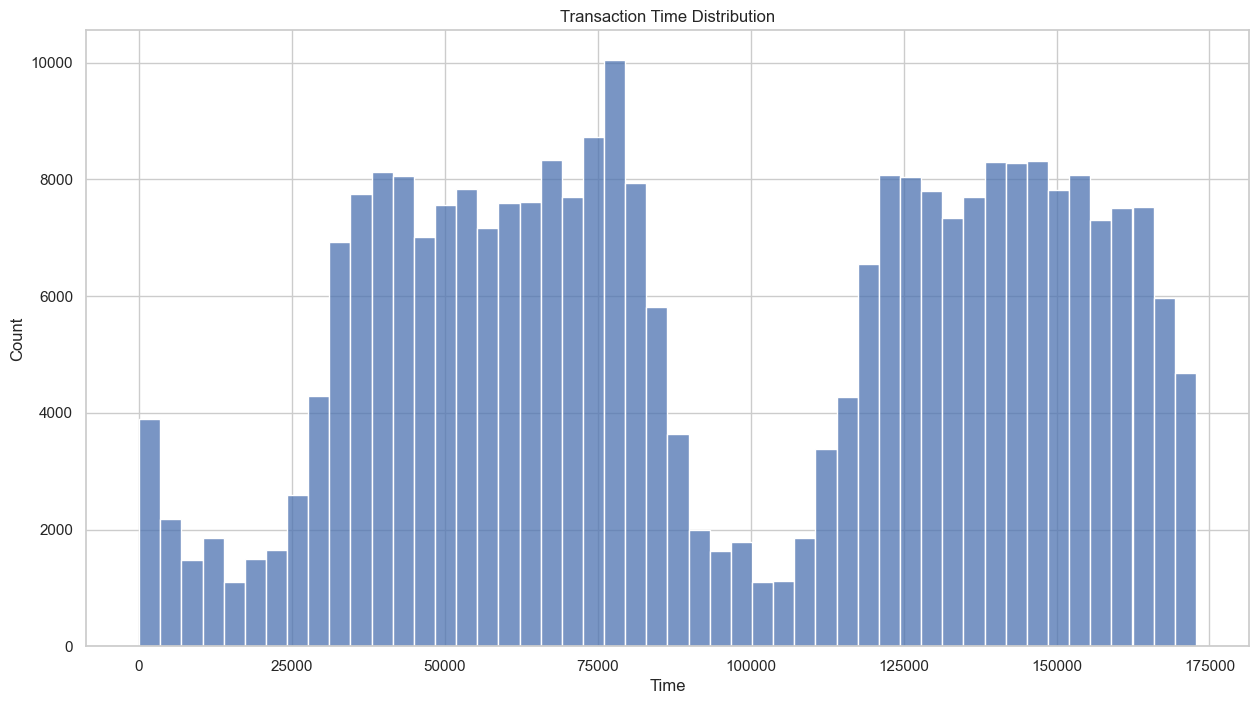

In [ ]:
plt.figure(figsize=(15,8))
sns.histplot(df["Time"], bins=50)
plt.title("Transaction Time Distribution")
plt.show()


This graph shows transactions that are spread across time. 
-   The data on x-axis goes from 0 to ~172,000 seconds or 48 hours
-   So, this dataset covers 2 days worth of transactions

Graphs shows non uniformity
-   Some time periods have high activity
-   Some time periods show low activity
-   There's clear dip in the middle around 90,000 to 100,000 seconds
    *   Fewer transactions
    *   May be due to night time or low activity period

Clear clusters of activity
-   First half (~ 0 to 80K) -> Active
-   Second half (~80K to 110K) -> Dip
-   Third half (~110K to 170K) -> Active again

Conclusion:
-   Transactions are time dependent
-   Transaction behavior changes depending on time
-   Fraud might also follow patterns

### Fraud vs Amount

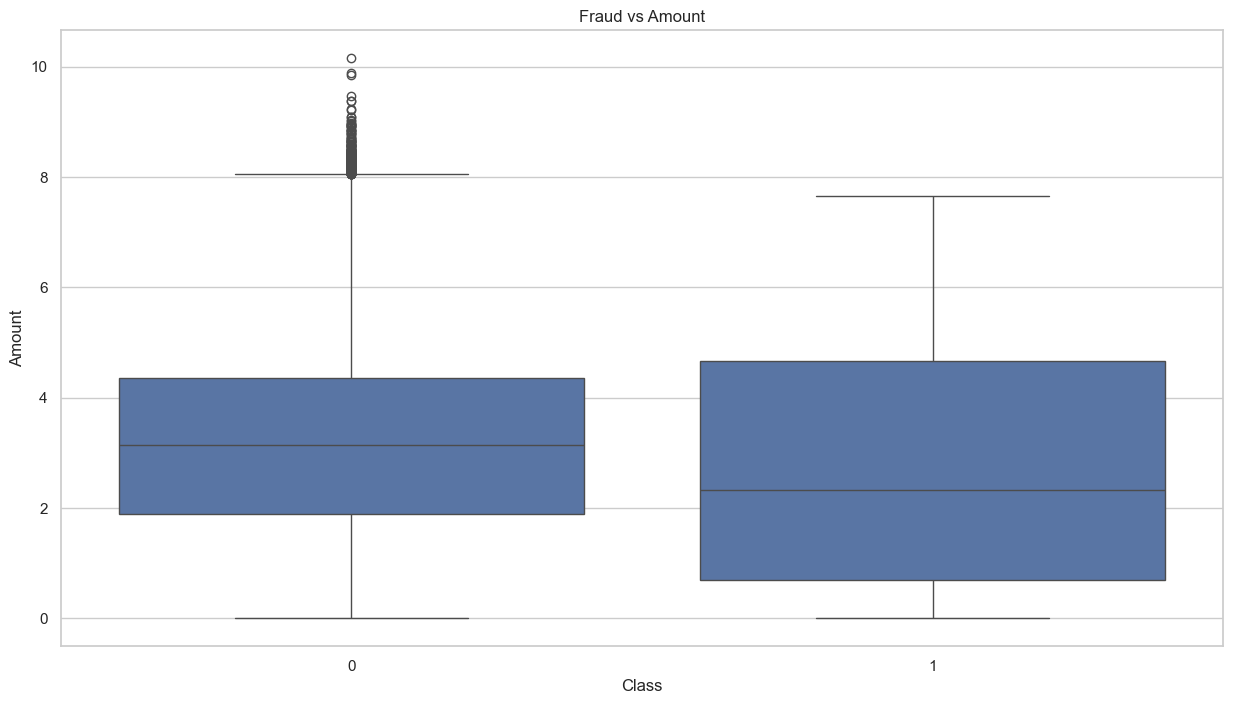

In [32]:
plt.figure(figsize=(15,8))
sns.boxplot(x="Class", y=np.log1p(df["Amount"]), data=df)
plt.title("Fraud vs Amount")
plt.show()


1.  Most transactions, both fraudulent and non-fraudulent, occur at low amounts
2.  Non-fraud transactions show a wide range with many high-value outliers
3.  Fraud transactions are mostly limited to smaller amounts
4.  This suggests fraudsters tend to perform smaller transactions to avoid detection
5.  Amount alone is not sufficient to distinguish fraud

Fraudulent transactions are generally smaller in value, while legitimate transactions can range from small to very large. This indicates fraudsters may try to avoid detection by keeping transaction amounts low. "Fraud hides in small transactions — not big ones.”

### Fraud vs Time

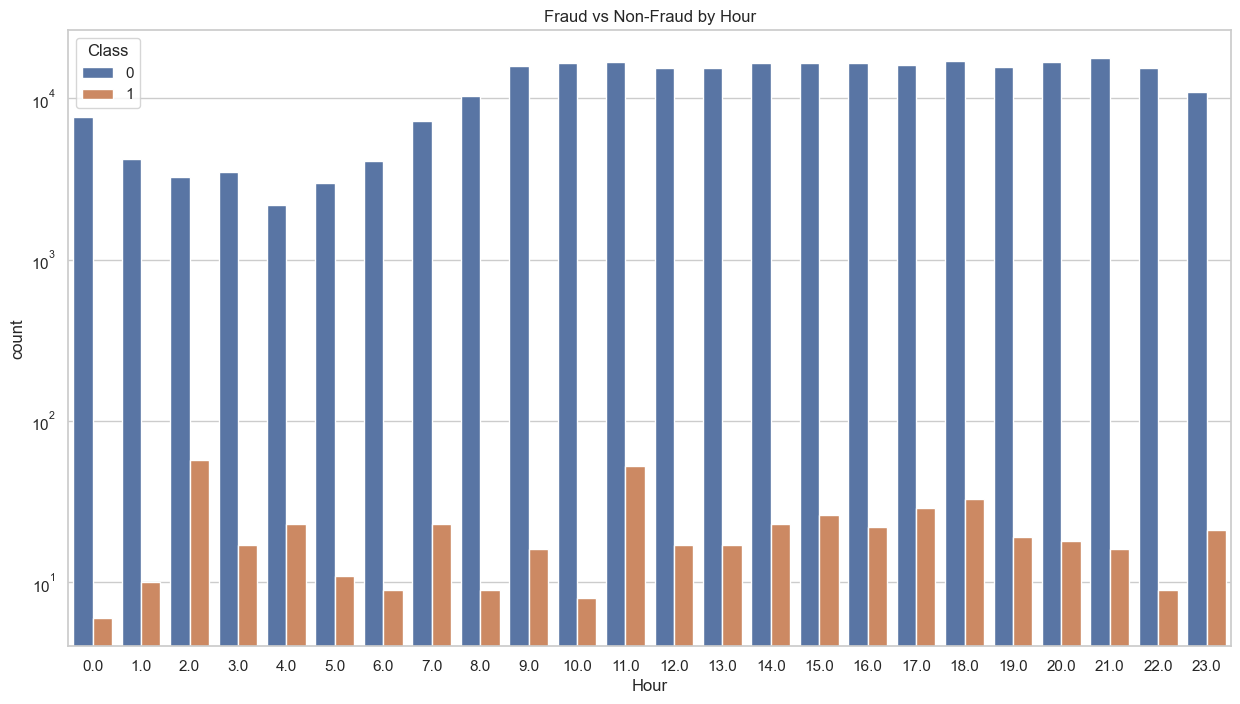

In [33]:
df["Hour"] = (df["Time"]//3600)%24
plt.figure(figsize=(15,8))
sns.countplot(x="Hour", hue="Class", data=df)
plt.yscale('log')
plt.title("Fraud vs Non-Fraud by Hour")
plt.show()

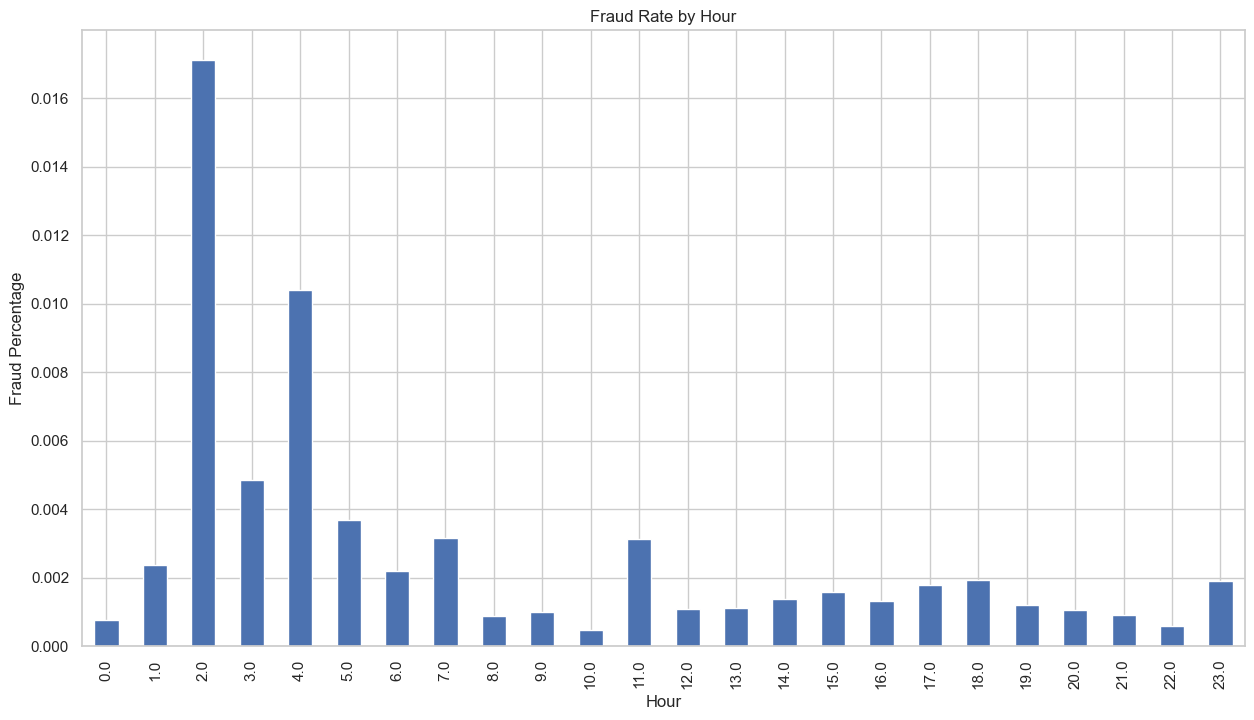

In [34]:
fraud_rate = df.groupby("Hour")["Class"].mean()

plt.figure(figsize=(15,8))
fraud_rate.plot(kind="bar")
plt.title("Fraud Rate by Hour")
plt.ylabel("Fraud Percentage")
plt.show()

1.  Transaction activity varies across different hours
2.  Fraud occurrence is not uniform across time
3.  Certain hours show relatively higher fraud rates
4.  This suggests time-based behavioral patterns can help in fraud detection

•	Created time-based features to capture behavioral patterns.  
•	Applied log transformation to handle skewness in transaction amount.  
•	Created amount buckets to group transactions into meaningful ranges.  
•	Generated interaction features to capture combined effects.  
•	These features help improve model performance and interpretability.  

## Phase-2
### Feature Engineering

In [35]:
# Applying log1p on amount to normalize the skewness of amount data
df["Log_Amount"] = np.log1p(df["Amount"])

# Amount range groups
df["Amount_Bucket"] = pd.cut(df["Amount"],
                             bins=[-1, 50, 200, 1000, 5000, 100000],
                             labels=["Very Low", "low", "Medium", "High", "Very High"])

# Feature to show busy vs quiet hours
df["Transaction_Count"] = df.groupby("Hour")["Amount"].transform("count")

# Amount and time relationship
df["Amt_Per_Hour"] = df["Amount"] / (df["Hour"]+1)

# Drop non important feature
df = df.drop(columns=["Time"])

df.info()

#df.head(50)

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 35 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   V1                 284807 non-null  float64 
 1   V2                 284807 non-null  float64 
 2   V3                 284807 non-null  float64 
 3   V4                 284807 non-null  float64 
 4   V5                 284807 non-null  float64 
 5   V6                 284807 non-null  float64 
 6   V7                 284807 non-null  float64 
 7   V8                 284807 non-null  float64 
 8   V9                 284807 non-null  float64 
 9   V10                284807 non-null  float64 
 10  V11                284807 non-null  float64 
 11  V12                284807 non-null  float64 
 12  V13                284807 non-null  float64 
 13  V14                284807 non-null  float64 
 14  V15                284807 non-null  float64 
 15  V16                284807 non-null  float64 


In [36]:
df.to_csv("/Users/thakur/Documents/Documents-Alok-MacBook-Air/LearnPython/SAFE-AI-Fraud-Investigation/data/processed/creditcard_processes.csv", index=False)
